# Script for plotting electrolyte properties (diffusivity and conductivity)

In [23]:
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
import pandas as pd
import scipy
from scipy.interpolate import CubicSpline
import matplotlib.ticker as tck
from pathlib import Path

# Global plotting defaults used by all figures in this notebook.
FONT = {"size": 12}
matplotlib.rc("font", **FONT)
plt.rcParams["axes.labelsize"] = 14

# Directory containing the exported EMSI CSV files for this study.
folder = Path("../raw_data")

## Plotting function

In [26]:
def plot_single(df, skip_last_cycles=None, ax=None, details=True, xlabel="", numbering=None):
    if ax == None:
        fig, ax = plt.subplots(1,1, figsize=(4.2, 3.36))
    cycle_nr = []
    i = 1

    if skip_last_cycles != None:
        cols = df.columns[1:-skip_last_cycles]
    else:
        cols = df.columns[1:]
    
    n_cycles = len(cols)
    cmap = plt.get_cmap('berlin', int(n_cycles*2.1))
    colors = [cmap(i) for i in range(cmap.N)]
        
    for col in cols:
        y_data = df[col].iloc[::1]
        x_data = df[df.columns[0]].iloc[::1]/1000

        if i == 1 or i == n_cycles:
            ax.plot(y_data, x_data, label=i, color=colors[i-1])
        else:
            ax.plot(y_data, x_data, color=colors[i-1])
        cycle_nr.append(i)
        i += 1
    
    if details:
        ax.legend(title="Cycle nr", loc="lower left")
        ax.set_xlabel(xlabel)
        ax.set_ylabel(r"$y$ [mm]")
    ax.grid(alpha=0.5)
    ax.grid(which="minor", alpha=0.5)
    ax.xaxis.set_minor_locator(tck.AutoMinorLocator(n=2))
    ax.yaxis.set_minor_locator(tck.AutoMinorLocator(n=2))
    ax.set_yticks(np.arange(0,30.1,10))
    ax.set_ylim(0, 30)
    if numbering != None:
        ax.text(numbering[0], ax.get_ylim()[1], numbering[1], weight="bold", verticalalignment="top")
    plt.tight_layout()
    return ax

## Plot diffusivity
##### The diffusivity is reduced in regions of high salt conentration and increased in regions of lower salt concentration

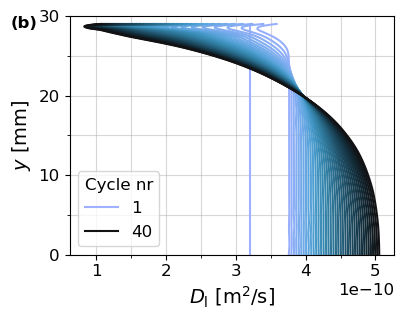

In [29]:
filename = "diffusivity.csv"

df = pd.read_csv(folder / filename, skiprows=7)

ax = plot_single(df, skip_last_cycles=2, xlabel = r"$D_\text{l}$ [$\text{m}^2$/s]", numbering=(-0.22e-10, "(b)"))
plt.tight_layout()
plt.savefig("../plots/" + filename[:-3] + "png", format="png", dpi=600)


## Plot conductivity
##### The conductivity is reduced in regions of high and low salt conentration, which leads to higher electrolyte overpotential

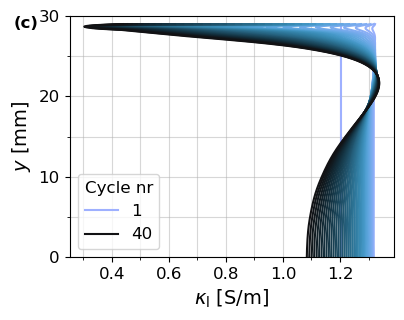

In [55]:
filename = "conductivity.csv"

df = pd.read_csv(folder / filename, skiprows=7)

ax = plot_single(df, skip_last_cycles=2, xlabel = r"$\kappa_\text{l}$ [$\text{S}$/m]",  numbering=(0.056, "(c)"))
ax.set_xticks(np.arange(0.4, 1.31, 0.2))
plt.tight_layout()
plt.savefig("../plots/" + filename[:-3] + "png", format="png", dpi=600)
